## BDD100k Data Analysis

some necessary imports

In [4]:
import json

from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import math
from collections import defaultdict
import seaborn as sns
import numpy as np

In [5]:
with open(r"D:\BOsch\assignment_data_bdd\bdd100k_labels_release\bdd100k\labels\bdd100k_labels_images_train.json") as f:
    train_json = json.load(f)

with open(r"D:\BOsch\assignment_data_bdd\bdd100k_labels_release\bdd100k\labels\bdd100k_labels_images_val.json") as f:
    val_json = json.load(f)

In [3]:
print('no of train samples jsons ',len(train_json))
print('no of val samples jsons ',len(val_json))
print(' checked , no. of images in train folder' , 70000)
print(' checked , no. of images in val folder' , 10000)

no of train samples jsons  69863
no of val samples jsons  10000
 checked , no. of images in train folder 70000
 checked , no. of images in val folder 10000


- This means , some images (137) labelling is missing in train json files
- So lets analyze whether there is any data missing in all those labels provided

In [4]:
category_counter = Counter(
    label["category"] 
    for item in train_json 
    for label in item.get("labels", [])
)

In [5]:
print(category_counter)

Counter({'car': 713211, 'lane': 528643, 'traffic sign': 239686, 'traffic light': 186117, 'drivable area': 125723, 'person': 91349, 'truck': 29971, 'bus': 11672, 'bike': 7210, 'rider': 4517, 'motor': 3002, 'train': 136})


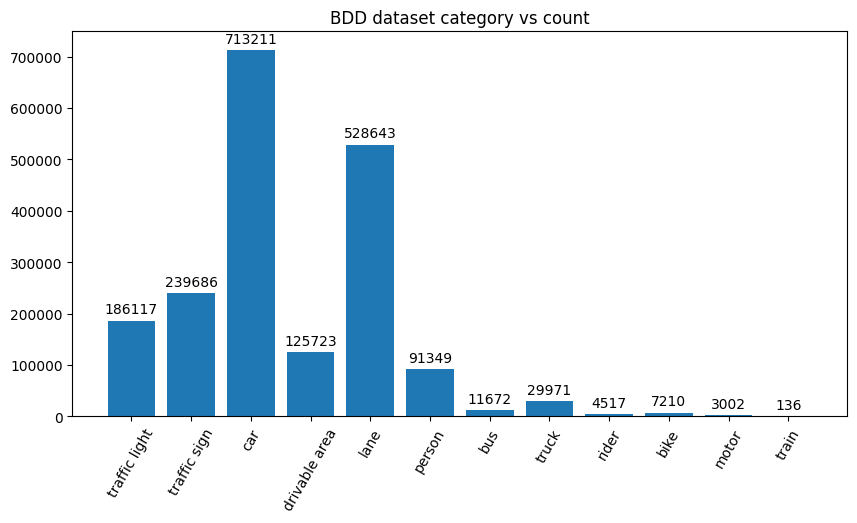

In [6]:
plt.figure(figsize=(10,5))
bars = plt.bar(category_counter.keys(), category_counter.values())
plt.bar_label(bars, padding=3)
plt.xticks(rotation=60)
plt.title("BDD dataset category vs count")
plt.show()

This shows that class are imbalanced , It creates doubt , whether each category follows a uniform data structure , or are there any data missing from json files of training section

In [7]:
category_fields = defaultdict(set) # empty set
for img in train_json:
    # Ensure "labels" exists and is a list
    labels = img.get("labels", [])
    for label in labels:
        cat = label.get("category", "Unknown") # Use .get to avoid another KeyError
        for key in label.keys():
            category_fields[cat].add(key)

category_fields


defaultdict(set,
            {'traffic light': {'attributes',
              'box2d',
              'category',
              'id',
              'manualAttributes',
              'manualShape'},
             'traffic sign': {'attributes',
              'box2d',
              'category',
              'id',
              'manualAttributes',
              'manualShape'},
             'car': {'attributes',
              'box2d',
              'category',
              'id',
              'manualAttributes',
              'manualShape'},
             'drivable area': {'attributes',
              'category',
              'id',
              'manualAttributes',
              'manualShape',
              'poly2d'},
             'lane': {'attributes',
              'category',
              'id',
              'manualAttributes',
              'manualShape',
              'poly2d'},
             'person': {'attributes',
              'box2d',
              'category',
              'id',
    

In [8]:
all_fields = sorted(list(set().union(*category_fields.values())))
all_fields

['attributes',
 'box2d',
 'category',
 'id',
 'manualAttributes',
 'manualShape',
 'poly2d']

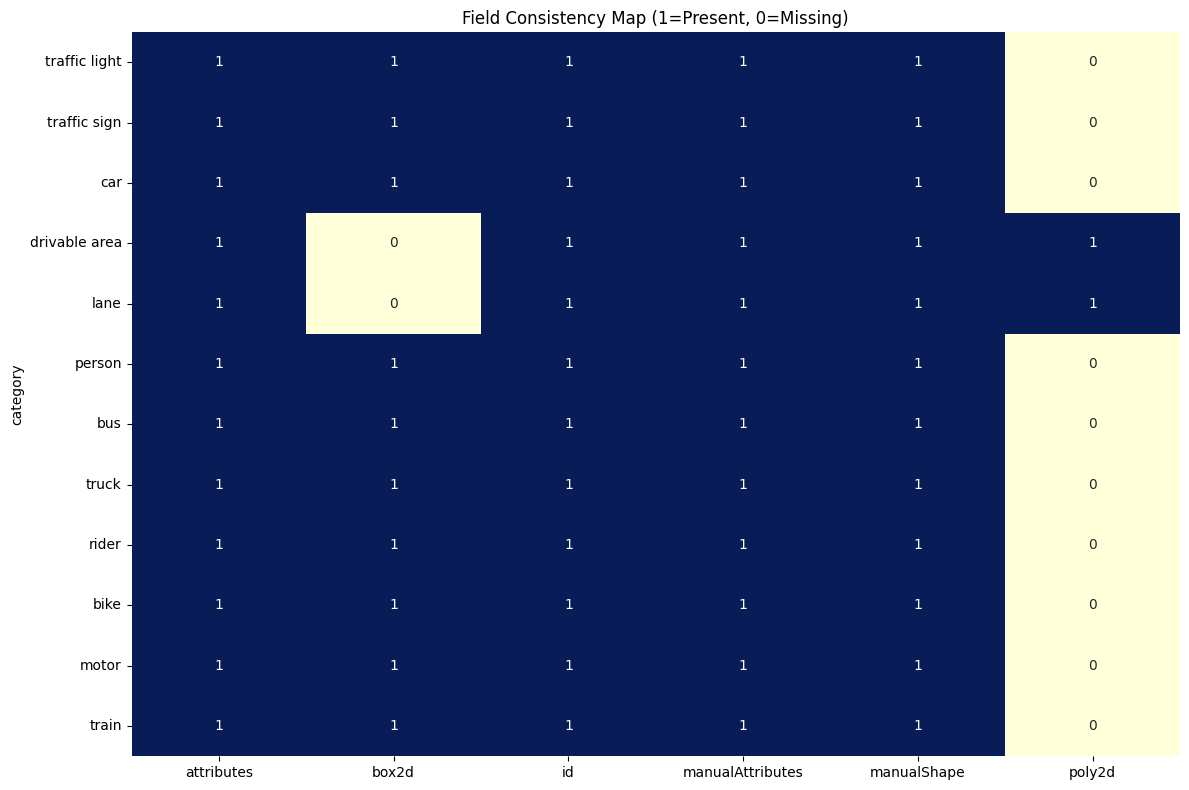

In [11]:
matrix_data = []
for cat, fields in category_fields.items():
    # True if the category has this attribute, False otherwise
    row = {field: (field in fields) for field in all_fields}
    row['category'] = cat
    matrix_data.append(row)

df = pd.DataFrame(matrix_data).set_index('category')


plt.figure(figsize=(12, 8))
# cmap="YlGnBu" makes it blue/green, annot=True shows 1 for True and 0 for False
sns.heatmap(df, annot=True, cmap="YlGnBu", cbar=False)
plt.title("Field Consistency Map (1=Present, 0=Missing)")
plt.tight_layout()
plt.show()

In [12]:
for img in train_json:
    # Safely get the list, default to empty list if missing
    for label in img.get("labels", []): 
        if label: # Ensure label isn't None
            category = label.get("category", "Unknown")
            category_fields[category].update(label.keys())

In [14]:

missing_report = defaultdict(Counter)
# Convert your missing_report into a readable DataFrame
report_list = []
for category, missing in missing_report.items():
    for field, count in missing.items():
        report_list.append({
            "Category": category,
            "Field": field,
            "Missing Count": count
        })

df_report = pd.DataFrame(report_list)

if not df_report.empty:
    print("\n--- Data Quality Issues Found ---")
    print(df_report.sort_values(by="Missing Count", ascending=False))
else:
    print("\nDataset is 100% consistent!")


Dataset is 100% consistent!


The  current script is checking the "surface level" keys, but it isn't diving into the nested dictionaries (the "inside to inside" data).
To solve this, there is a  need to flatten the keys. Instead of just recording "attributes", also there is need  to record "attributes.occluded", "attributes.truncated", etc.

In [15]:
def get_deep_keys(d, parent_key=''):
    """Recursively finds all nested keys in a dictionary."""
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}.{k}" if parent_key else k
        items.append(new_key)
        if isinstance(v, dict):
            items.extend(get_deep_keys(v, new_key))
    return items


In [16]:
category_fields = defaultdict(set)

for img in train_json:
    for label in img.get("labels", []):
        category = label["category"]
        # This now gets ['id', 'attributes', 'attributes.occluded', etc.]
        deep_keys = get_deep_keys(label)
        category_fields[category].update(deep_keys)

# Step 2: Check missing nested fields
missing_report = defaultdict(Counter)

for img in train_json:
    for label in img.get("labels", []):
        category = label["category"]
        expected_fields = category_fields[category]
        actual_keys = set(get_deep_keys(label))

        for field in expected_fields:
            if field not in actual_keys:
                missing_report[category][field] += 1

# Step 3: Print Detailed Results
for category in sorted(category_fields.keys()):
    print(f"\nCategory: {category}")
    if category in missing_report:
        print("❌ Inconsistencies found:")
        # Sort by most missing to least missing
        for field, count in missing_report[category].most_common():
            print(f"   - {field:.<30} missing in {count} objects")
    else:
        print("✅ 100% Consistent (Nested levels included)")


Category: bike
✅ 100% Consistent (Nested levels included)

Category: bus
✅ 100% Consistent (Nested levels included)

Category: car
✅ 100% Consistent (Nested levels included)

Category: drivable area
✅ 100% Consistent (Nested levels included)

Category: lane
✅ 100% Consistent (Nested levels included)

Category: motor
✅ 100% Consistent (Nested levels included)

Category: person
✅ 100% Consistent (Nested levels included)

Category: rider
✅ 100% Consistent (Nested levels included)

Category: traffic light
✅ 100% Consistent (Nested levels included)

Category: traffic sign
✅ 100% Consistent (Nested levels included)

Category: train
✅ 100% Consistent (Nested levels included)

Category: truck
✅ 100% Consistent (Nested levels included)


With the dataset schema validated, the next step is a deep dive into how each image is being described

through json files , understanding for how the data is represented is given 
- first given is scene context  ("weather -> clear",
   "scene -> city street",
   "timeofday ->daytime" )
   - it can be used for scene analysis
- secondly given attrubites related to whatever objects detected there

   - if car  present then bbox info related to where it is present is given
   - if its a trafiic light then its location in image , what color it is showing 

     "occluded": false,
   "truncated": false,
   "trafficLightColor": "none"

- third is drivable area attribute and polygon labels to give the region

   "category": "drivable area",
    "attributes": {
   "areaType": "direct"
    }

now curiosity is to look , 
how many different type of weathers are  given
how many differnet type of scens are present
how many differnet type of timeofday are present

then i would love to see 
bboxes distributed in cars , truck ...etc etc 
whichi is largest  , which is smallest
area marked in terms of bbox for the vehicles or among pedesstrian
one image where pedestrian might be as tiny as a lilliputian

also about traffic lights , 
how many traffic lights shows occluded true 
truncated true

in all those cases , traffic light color  will be detected as none

then i woulld love to see 
distribution of drivable area 
and what are differnet types of are given in the dataset






In [15]:
from collections import defaultdict

attribute_types = defaultdict(set)

for img in train_json:

    # image-level
    for k, v in img.get("attributes", {}).items():
        attribute_types[k].add(v)

    for label in img.get("labels", []):
        for k, v in label.get("attributes", {}).items():
            attribute_types[k].add(v)

print("\nAll Attributes Found:\n")

for attr, values in attribute_types.items():
    print(attr, "->", list(values))


All Attributes Found:

weather -> ['clear', 'rainy', 'snowy', 'undefined', 'overcast', 'partly cloudy', 'foggy']
scene -> ['gas stations', 'tunnel', 'residential', 'parking lot', 'highway', 'city street', 'undefined']
timeofday -> ['night', 'undefined', 'daytime', 'dawn/dusk']
occluded -> [False, True]
truncated -> [False, True]
trafficLightColor -> ['yellow', 'none', 'green', 'red']
areaType -> ['alternative', 'direct']
laneDirection -> ['vertical', 'parallel']
laneStyle -> ['solid', 'dashed']
laneType -> ['double other', 'double white', 'single white', 'single yellow', 'double yellow', 'crosswalk', 'road curb', 'single other']


In [27]:


def plot_attribute_distribution(json_data, attribute_name, level="image", category=None):

    values = []

    for img in json_data:

        # IMAGE LEVEL ATTRIBUTES
        if level == "image":
            attrs = img.get("attributes", {})
            if attribute_name in attrs:
                values.append(attrs[attribute_name])

        # OBJECT LEVEL ATTRIBUTES
        elif level == "object":

            for label in img.get("labels", []):

                if category and label["category"] != category:
                    continue

                attrs = label.get("attributes", {})
                if attribute_name in attrs:
                    values.append(attrs[attribute_name])

    if not values:
        print("No values found for this attribute")
        return

    counts = Counter(values)

    plt.figure(figsize=(8,6))
    bars = plt.bar(counts.keys(), counts.values())
    plt.bar_label(bars, padding=3)

    plt.title(f"Distribution of {attribute_name}")
    plt.xlabel(attribute_name)
    plt.ylabel("Count")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()




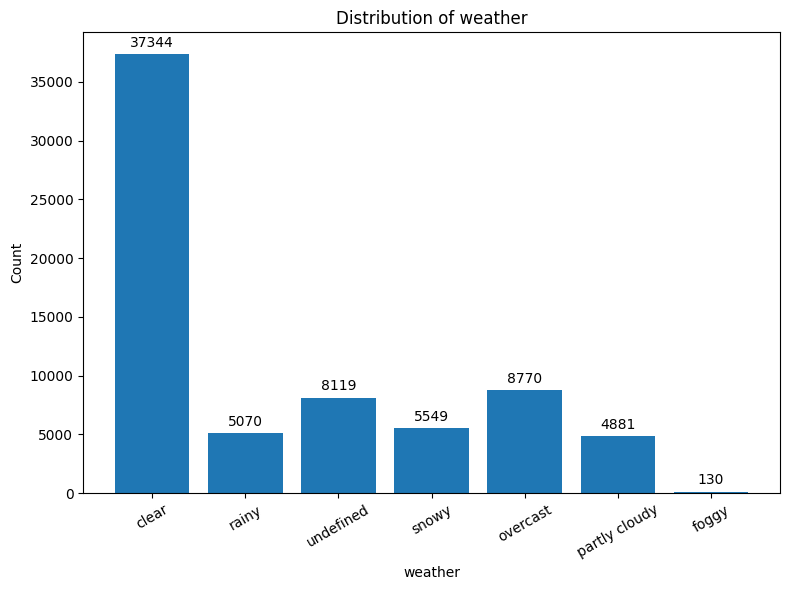

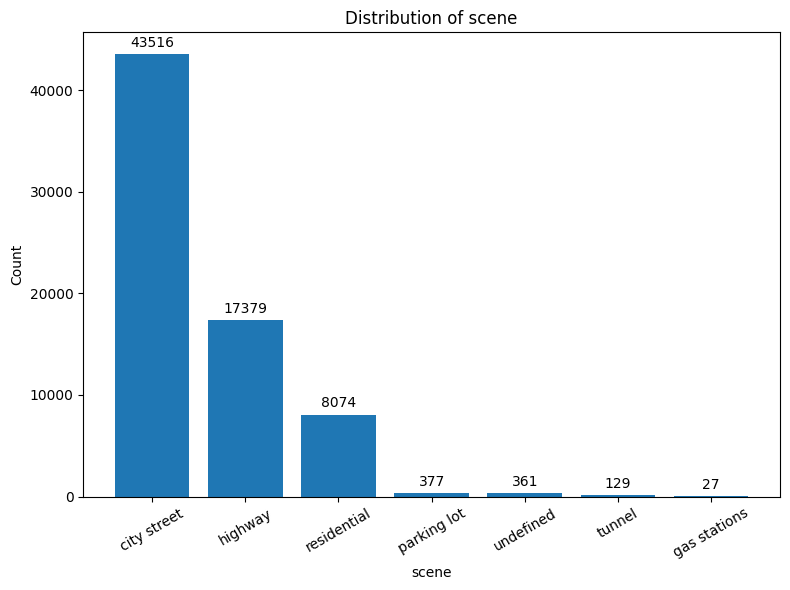

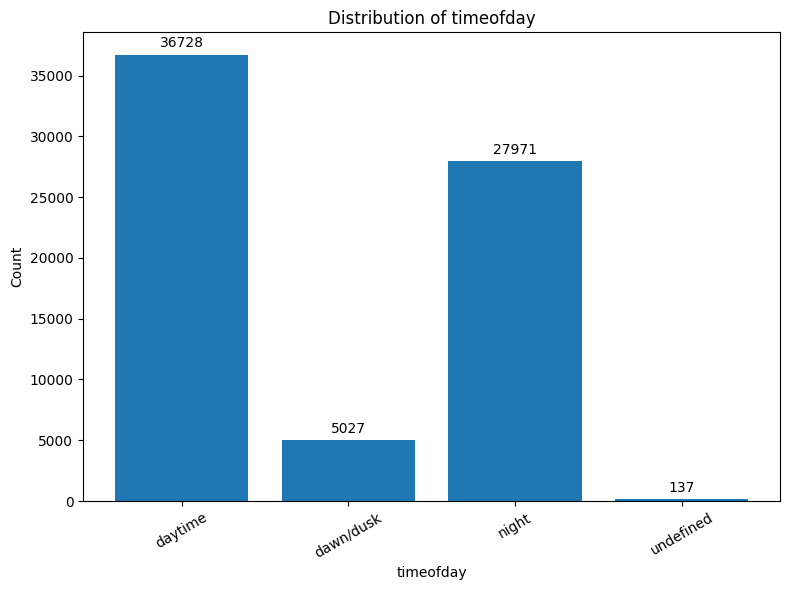

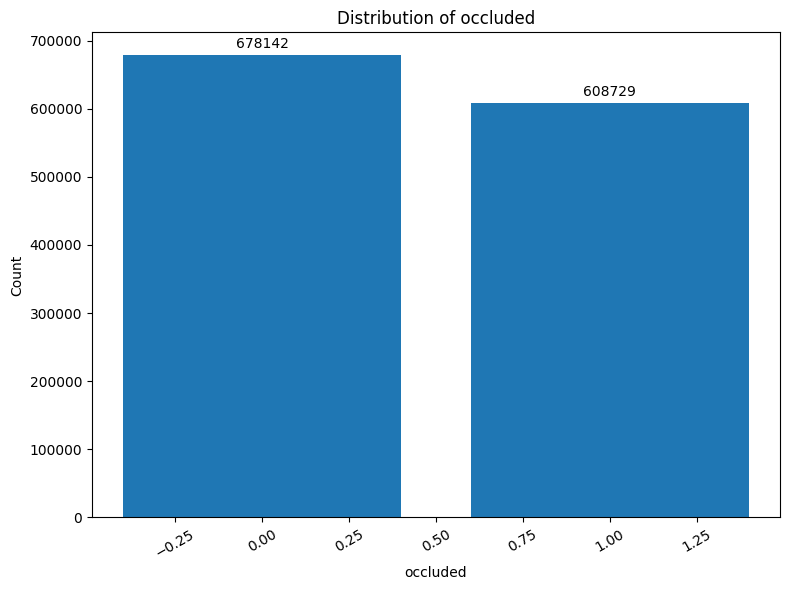

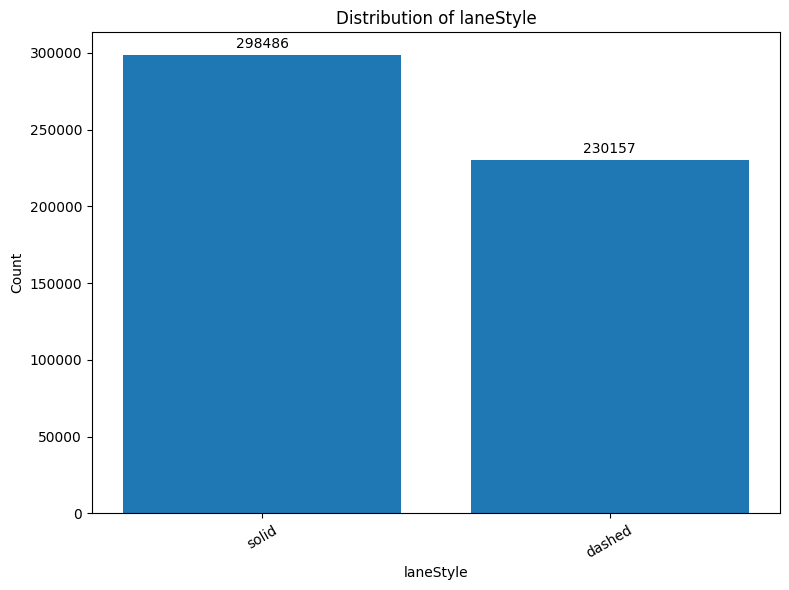

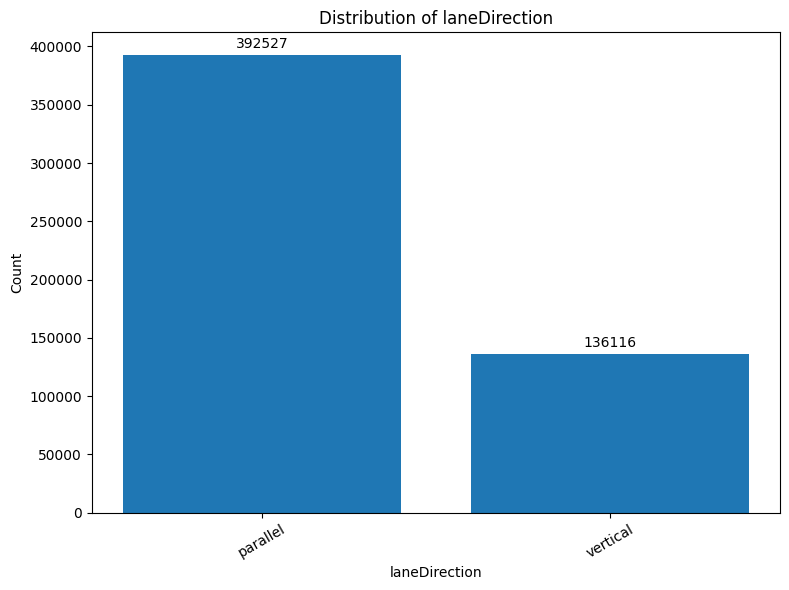

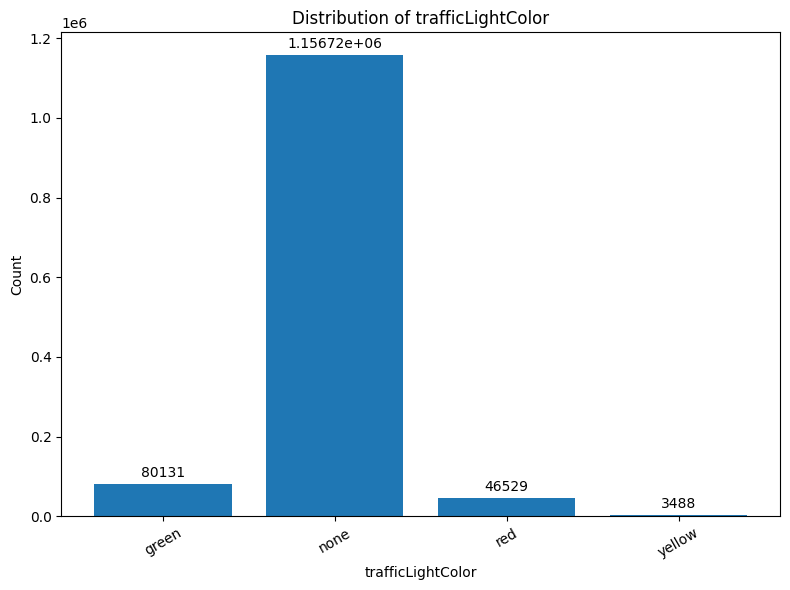

In [33]:
plot_attribute_distribution(train_json, "weather", level="image")
plot_attribute_distribution(train_json, "scene", level="image")
plot_attribute_distribution(train_json, "timeofday", level="image")
plot_attribute_distribution(train_json, "occluded", level="object")

plot_attribute_distribution(
    train_json,
    "laneStyle",
    level="object",
    category="lane"
)

plot_attribute_distribution(
    train_json,
    "laneDirection",
    level="object",
    category="lane"
)


plot_attribute_distribution(
    train_json,
    "trafficLightColor",
    level="object"
)

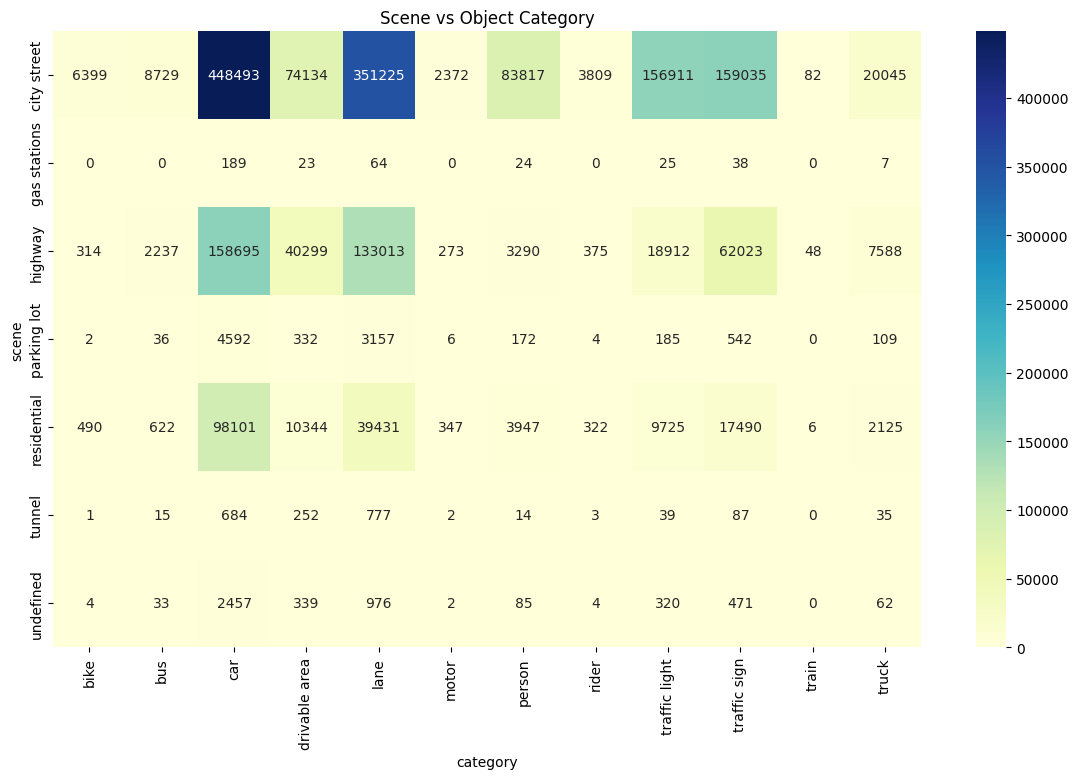

In [ ]:

rows = []

for img in train_json:

    scene = img["attributes"]["scene"]

    for label in img.get("labels", []):
        rows.append({
            "scene": scene,
            "category": label["category"]
        })

df = pd.DataFrame(rows)

pivot = pd.crosstab(df["scene"], df["category"])

plt.figure(figsize=(14,8))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu")

plt.title("Scene vs Object Category")
plt.show()

In [52]:


def plot_vs(json_data, x_attr, y_attr, y_category=None):

    rows = []

    for img in json_data:

        img_attrs = img.get("attributes", {})

        for label in img.get("labels", []):

            label_attrs = label.get("attributes", {})

            # optional filter (example: only lanes)
            if y_category and label["category"] != y_category:
                continue

            # get x value
            if x_attr in img_attrs:
                x_val = img_attrs[x_attr]
            elif x_attr == "category":
                x_val = label["category"]
            else:
                x_val = label_attrs.get(x_attr)

            # get y value
            if y_attr in img_attrs:
                y_val = img_attrs[y_attr]
            elif y_attr == "category":
                y_val = label["category"]
            else:
                y_val = label_attrs.get(y_attr)

            if x_val is not None and y_val is not None:
                rows.append({x_attr: x_val, y_attr: y_val})

    df = pd.DataFrame(rows)

    if df.empty:
        print("No data found for this combination")
        return

    pivot = pd.crosstab(df[x_attr], df[y_attr])

    plt.figure(figsize=(14,8))
    sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu")

    plt.title(f"{x_attr} vs {y_attr}")
    plt.xlabel(y_attr)
    plt.ylabel(x_attr)

    plt.tight_layout()
    plt.show()

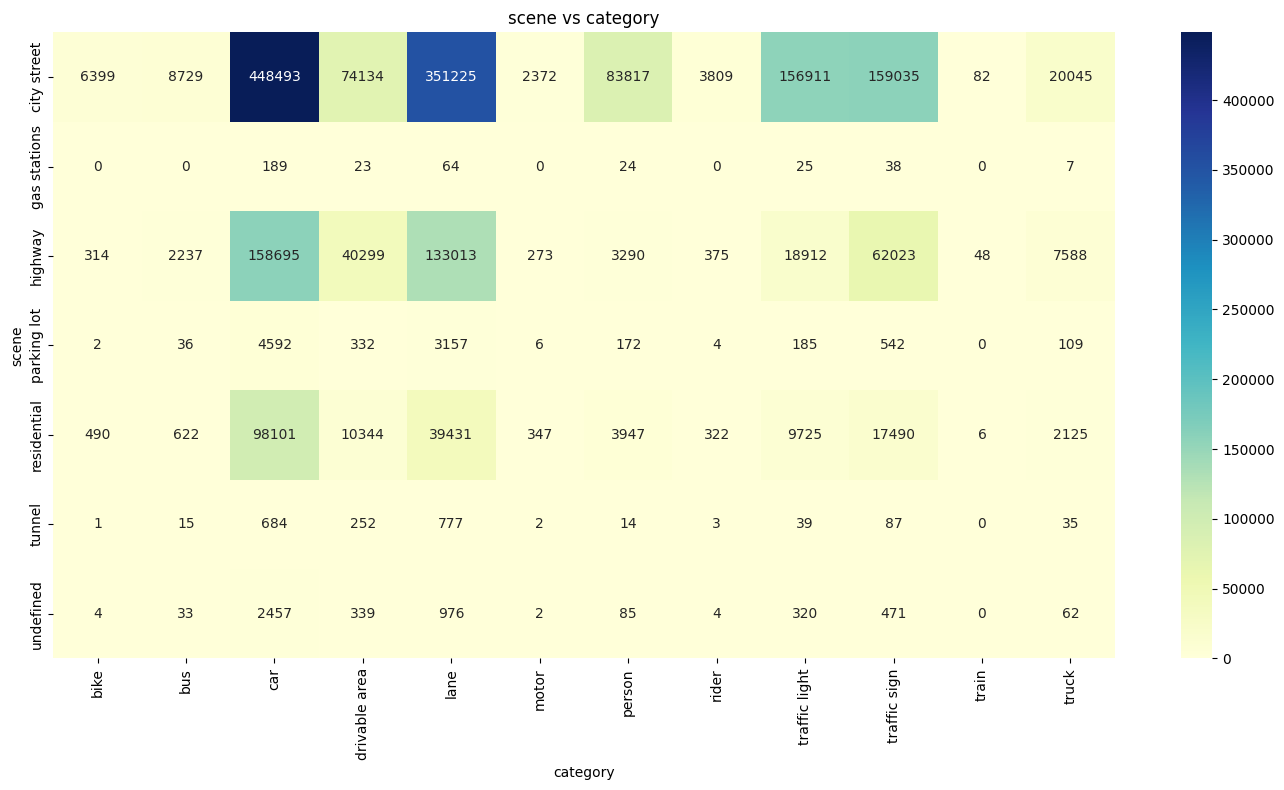

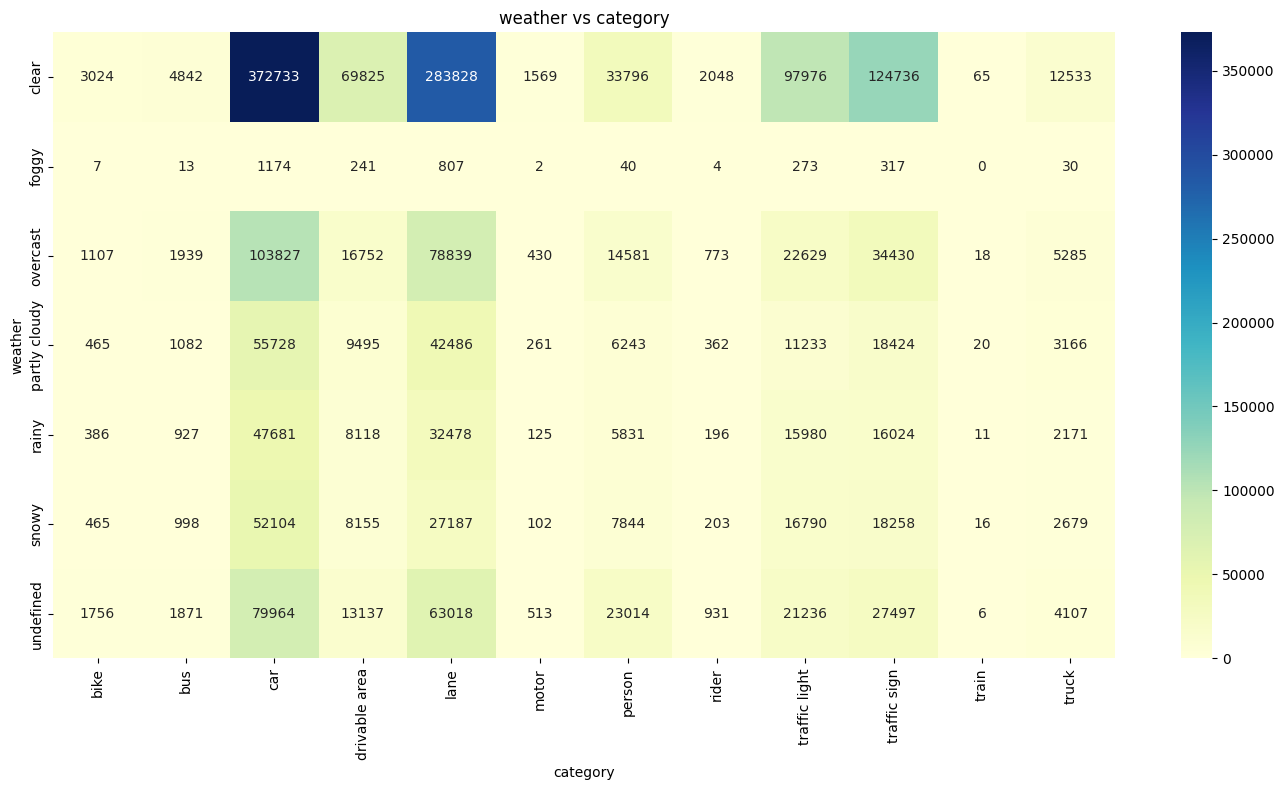

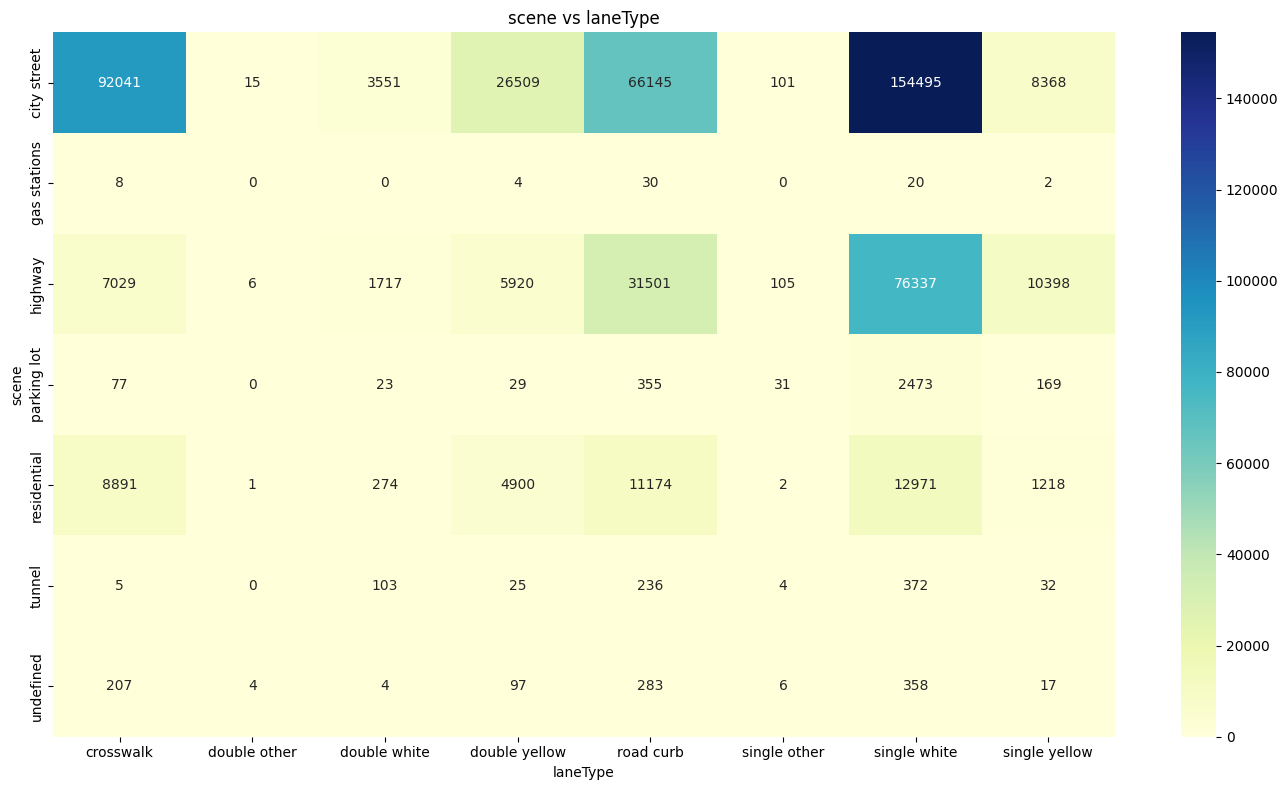

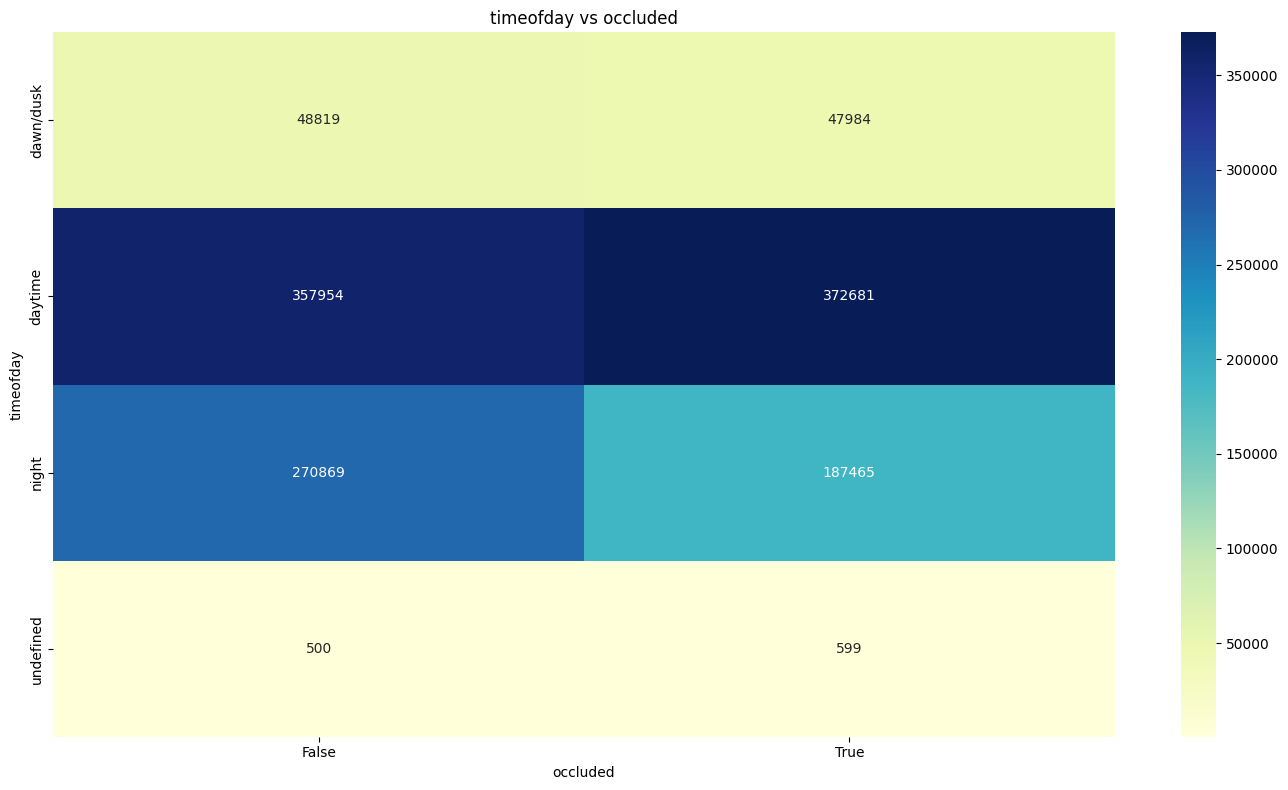

In [53]:
plot_vs(train_json, "scene", "category")
plot_vs(train_json, "weather", "category")
plot_vs(train_json, "scene", "laneType", "lane")
plot_vs(train_json, "timeofday", "occluded")

In [48]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def show_bdd_image(image_name, json_data, image_folder):

    img_data = None
    for img in json_data:
        if img["name"] == image_name:
            img_data = img
            break

    if img_data is None:
        print("Image annotation not found")
        return

    img_path = os.path.join(image_folder, image_name)
    image = Image.open(img_path)

    fig, ax = plt.subplots(1, figsize=(12,8))
    ax.imshow(image)

    for label in img_data.get("labels", []):

        category = label["category"]

        # -------- BOX OBJECTS --------
        if "box2d" in label:

            box = label["box2d"]
            x1, y1 = box["x1"], box["y1"]
            x2, y2 = box["x2"], box["y2"]

            width = x2 - x1
            height = y2 - y1

            rect = patches.Rectangle(
                (x1, y1),
                width,
                height,
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )

            ax.add_patch(rect)
            ax.text(x1, y1-5, category, color="yellow", fontsize=8)

        # -------- LANE / POLYGON OBJECTS --------
        if "poly2d" in label:

            for poly in label["poly2d"]:

                vertices = poly["vertices"]
                xs = [v[0] for v in vertices]
                ys = [v[1] for v in vertices]

                ax.plot(xs, ys, color="cyan", linewidth=3)

    plt.title(image_name)
    plt.axis("off")
    plt.show()

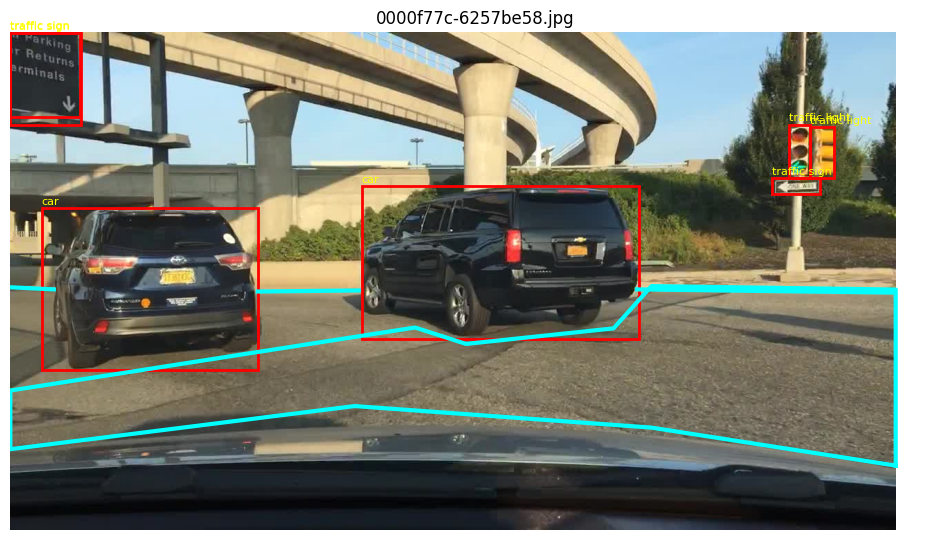

In [49]:
show_bdd_image(
    "0000f77c-6257be58.jpg",
    train_json,
    r"D:\BOsch\assignment_data_bdd\bdd100k_images_100k\bdd100k\images\100k\train"
)

In [46]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def show_bdd_image_with_lane(image_name, json_data, image_folder):

    img_data = None
    for img in json_data:
        if img["name"] == image_name:
            img_data = img
            break

    if img_data is None:
        print("Image annotation not found")
        return

    img_path = os.path.join(image_folder, image_name)
    image = Image.open(img_path)

    fig, ax = plt.subplots(figsize=(12,8))
    ax.imshow(image)

    for label in img_data.get("labels", []):

        category = label["category"]

        # ------------------
        # Bounding boxes
        # ------------------
        if "box2d" in label:

            box = label["box2d"]
            x1, y1 = box["x1"], box["y1"]
            x2, y2 = box["x2"], box["y2"]

            rect = patches.Rectangle(
                (x1, y1),
                x2-x1,
                y2-y1,
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )

            ax.add_patch(rect)
            ax.text(x1, y1-5, category, color="yellow", fontsize=8)

        # ------------------
        # Lanes
        # ------------------
        if category == "lane" and "poly2d" in label:

            for poly in label["poly2d"]:

                vertices = poly["vertices"]
                xs = [v[0] for v in vertices]
                ys = [v[1] for v in vertices]

                ax.plot(xs, ys, color="cyan", linewidth=3)

        # ------------------
        # Drivable area
        # ------------------
        if category == "drivable area" and "poly2d" in label:

            for poly in label["poly2d"]:

                vertices = poly["vertices"]

                polygon = patches.Polygon(
                    vertices,
                    closed=True,
                    facecolor="green",
                    edgecolor="green",
                    alpha=0.25
                )

                ax.add_patch(polygon)

    plt.title(image_name)
    plt.axis("off")
    plt.show()

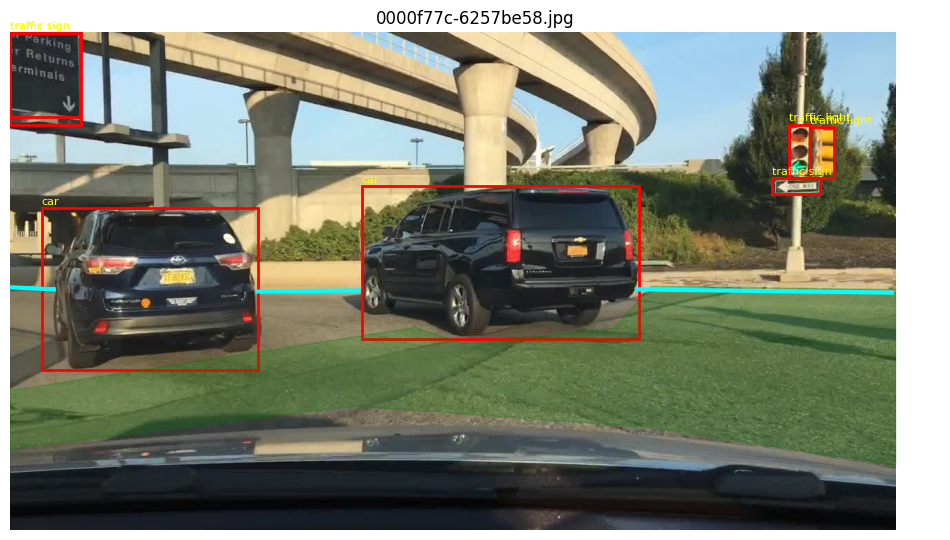

In [54]:
show_bdd_image_with_lane(
    "0000f77c-6257be58.jpg",
    train_json,
    r"D:\BOsch\assignment_data_bdd\bdd100k_images_100k\bdd100k\images\100k\train"
)